# BrainScanAI — Analyse non supervisée et clustering

## Objectifs

Cette étape vise à :

- standardiser les embeddings extraits par ResNet-50 ;
- réduire leur dimension avec PCA ;
- produire des visualisations PCA et t-SNE ;
- comparer plusieurs algorithmes de clustering ;
- rechercher deux groupes correspondant potentiellement aux classes
  `normal` et `cancer` ;
- évaluer les regroupements sur les 100 images fortement annotées avec
  l'Adjusted Rand Index ;
- préparer une labellisation faible des 1 406 images non annotées.

## Séparation des données

Les labels experts ne sont jamais transmis aux algorithmes de clustering.

Ils sont utilisés uniquement après le clustering pour :

- calculer l'ARI ;
- interpréter la composition des clusters ;
- associer ultérieurement un sens médical prudent aux identifiants de clusters.

Le futur fichier de labels faibles sera conservé séparément du fichier
contenant les labels experts.

## 1. Imports et configuration

In [157]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [158]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Imports réussis.")

Imports réussis.


## 2. Chargement des embeddings

Les matrices `layer3` et `avgpool` générées à l'étape précédente sont
rechargées avec leurs métadonnées.

Les fichiers se trouvent dans `data/processed` et restent exclus de Git.

In [159]:
def trouver_racine_projet(repertoire_depart: Path) -> Path:
    """
    Recherche la racine du projet contenant pyproject.toml.
    """

    for candidat in (
        repertoire_depart,
        *repertoire_depart.parents,
    ):
        if (candidat / "pyproject.toml").exists():
            return candidat

    raise FileNotFoundError(
        "Impossible de localiser la racine du projet."
    )


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = trouver_racine_projet(CURRENT_DIR)

FEATURES_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "resnet50_imagenet1k_v2"
)

LAYER3_PATH = FEATURES_DIR / "embeddings_layer3.npy"
AVGPOOL_PATH = FEATURES_DIR / "embeddings_avgpool.npy"
METADATA_PATH = FEATURES_DIR / "metadata.csv"

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clustering"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Features : {FEATURES_DIR}")
print(f"Sorties clustering : {OUTPUT_DIR}")
print()

print(f"Layer3 présent : {LAYER3_PATH.exists()}")
print(f"Avgpool présent : {AVGPOOL_PATH.exists()}")
print(f"Métadonnées présentes : {METADATA_PATH.exists()}")

Features : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/features/resnet50_imagenet1k_v2
Sorties clustering : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/clustering

Layer3 présent : True
Avgpool présent : True
Métadonnées présentes : True


In [160]:
X_layer3 = np.load(
    LAYER3_PATH,
).astype(np.float32)

X_avgpool = np.load(
    AVGPOOL_PATH,
).astype(np.float32)

df_metadata = pd.read_csv(
    METADATA_PATH,
)

print(f"Layer3 : {X_layer3.shape}")
print(f"Avgpool : {X_avgpool.shape}")
print(f"Métadonnées : {df_metadata.shape}")

Layer3 : (1506, 1024)
Avgpool : (1506, 2048)
Métadonnées : (1506, 10)


In [161]:
assert X_layer3.shape == (1506, 1024)
assert X_avgpool.shape == (1506, 2048)
assert len(df_metadata) == 1506

assert np.isfinite(X_layer3).all()
assert np.isfinite(X_avgpool).all()

print("Embeddings et métadonnées validés.")

Embeddings et métadonnées validés.


7. Séparer fortement et non labellisé

## 3. Séparation stricte des données

Deux index distincts sont créés :

- `strong_mask` pour les 100 images disposant d'un label expert ;
- `unlabeled_mask` pour les 1 406 images sans label.

Aucun label faible ne sera ajouté dans le tableau des labels experts.

In [162]:
strong_mask = (
    df_metadata["label"]
    .notna()
    .to_numpy()
)

unlabeled_mask = (
    df_metadata["label"]
    .isna()
    .to_numpy()
)

df_strong_reference = (
    df_metadata.loc[strong_mask]
    .reset_index(drop=True)
    .copy()
)

df_unlabeled_reference = (
    df_metadata.loc[unlabeled_mask]
    .reset_index(drop=True)
    .copy()
)

y_strong = (
    df_strong_reference["label_id"]
    .astype(int)
    .to_numpy()
)

print(
    "Images fortement labellisées :",
    len(df_strong_reference),
)

print(
    "Images non labellisées :",
    len(df_unlabeled_reference),
)

display(
    df_strong_reference["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="nombre_images")
)

Images fortement labellisées : 100
Images non labellisées : 1406


,label,nombre_images
0,cancer,50
1,normal,50


In [163]:
assert len(df_strong_reference) == 100
assert len(df_unlabeled_reference) == 1406
assert not df_strong_reference["label"].isna().any()
assert df_unlabeled_reference["label"].isna().all()

print("Séparation des données : OK")

Séparation des données : OK


8. Standardisation et PCA

La PCA est une réduction linéaire qui projette les données dans un espace de dimension inférieure. Comme PCA centre les données mais ne les standardise pas feature par feature, nous appliquons explicitement StandardScaler avant elle.

## 4. Standardisation et réduction de dimension

Pour chaque représentation :

1. les features sont standardisées ;
2. une PCA conserve au moins 95 % de la variance ;
3. une PCA à deux dimensions est créée pour la visualisation ;
4. une projection t-SNE est calculée à partir d'au plus 50 composantes PCA.

Les labels experts ne sont utilisés dans aucune de ces opérations.

In [164]:
def preparer_representation(
    X: np.ndarray,
    nom: str,
) -> dict:
    """
    Standardise une matrice puis construit les projections PCA et t-SNE.
    """

    scaler = StandardScaler()

    X_standardise = scaler.fit_transform(
        X
    ).astype(np.float32)

    pca_clustering = PCA(
        n_components=0.95,
        svd_solver="full",
    )

    X_pca_clustering = pca_clustering.fit_transform(
        X_standardise
    ).astype(np.float32)

    pca_2d = PCA(
        n_components=2,
        svd_solver="full",
    )

    X_pca_2d = pca_2d.fit_transform(
        X_standardise
    ).astype(np.float32)

    nombre_tsne = min(
        50,
        X_pca_clustering.shape[1],
    )

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        max_iter=1_000,
        random_state=RANDOM_STATE,
    )

    X_tsne_2d = tsne.fit_transform(
        X_pca_clustering[:, :nombre_tsne]
    ).astype(np.float32)

    return {
        "nom": nom,
        "scaler": scaler,
        "pca_clustering": pca_clustering,
        "pca_2d": pca_2d,
        "tsne": tsne,
        "X_standardise": X_standardise,
        "X_clustering": X_pca_clustering,
        "X_pca_2d": X_pca_2d,
        "X_tsne_2d": X_tsne_2d,
        "variance_conservee": float(
            pca_clustering
            .explained_variance_ratio_
            .sum()
        ),
    }

In [165]:
espaces = {
    "layer3": preparer_representation(
        X_layer3,
        "layer3",
    ),
    "avgpool": preparer_representation(
        X_avgpool,
        "avgpool",
    ),
}

In [166]:
resume_pca = []

for nom, espace in espaces.items():
    resume_pca.append(
        {
            "representation": nom,
            "dimensions_initiales": (
                X_layer3.shape[1]
                if nom == "layer3"
                else X_avgpool.shape[1]
            ),
            "composantes_pca": (
                espace["X_clustering"].shape[1]
            ),
            "variance_conservee": (
                espace["variance_conservee"]
            ),
        }
    )

df_resume_pca = pd.DataFrame(
    resume_pca
)

display(df_resume_pca)

,representation,dimensions_initiales,composantes_pca,variance_conservee
0,layer3,1024,320,0.95018
1,avgpool,2048,682,0.95014


9. Visualiser PCA et t-SNE

t-SNE est une méthode de visualisation non linéaire. Son optimisation n’est pas convexe, donc des initialisations différentes peuvent produire des projections différentes. Nous fixons donc random_state=42. Elle ne sera pas utilisée pour entraîner K-Means ou DBSCAN.

In [167]:
def creer_table_projection(
    espace: dict,
) -> pd.DataFrame:
    """
    Construit un tableau contenant les projections 2D.
    """

    dataframe = df_metadata[
        [
            "chemin_relatif",
            "nom_fichier",
            "categorie",
            "label",
        ]
    ].copy()

    dataframe["source_label"] = np.where(
        dataframe["label"].notna(),
        "fortement_labellisé",
        "non_labellisé",
    )

    dataframe["pca_1"] = (
        espace["X_pca_2d"][:, 0]
    )

    dataframe["pca_2"] = (
        espace["X_pca_2d"][:, 1]
    )

    dataframe["tsne_1"] = (
        espace["X_tsne_2d"][:, 0]
    )

    dataframe["tsne_2"] = (
        espace["X_tsne_2d"][:, 1]
    )

    return dataframe

In [168]:
projections = {
    nom: creer_table_projection(espace)
    for nom, espace in espaces.items()
}

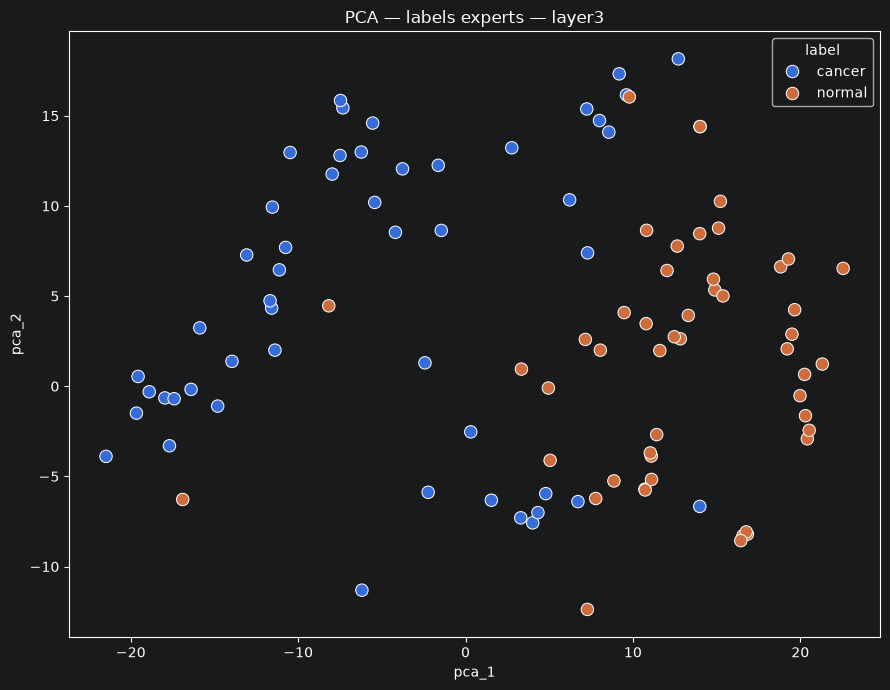

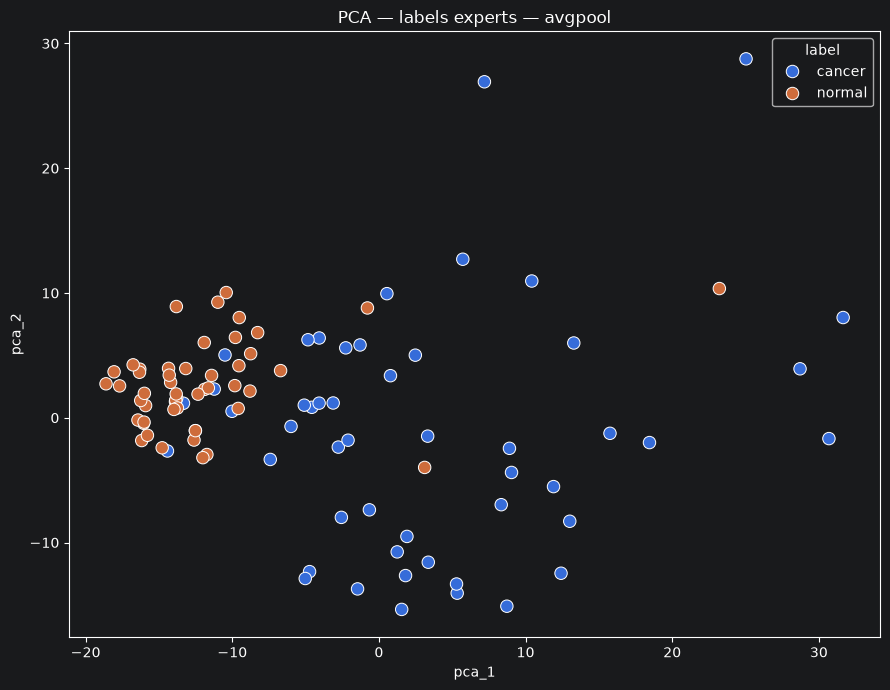

In [169]:
for nom, dataframe in projections.items():
    donnees_fortes = dataframe[
        dataframe["label"].notna()
    ]

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=donnees_fortes,
        x="pca_1",
        y="pca_2",
        hue="label",
        s=80,
    )

    plt.title(
        f"PCA — labels experts — {nom}"
    )

    plt.tight_layout()
    plt.show()

Puis en t-SNE :

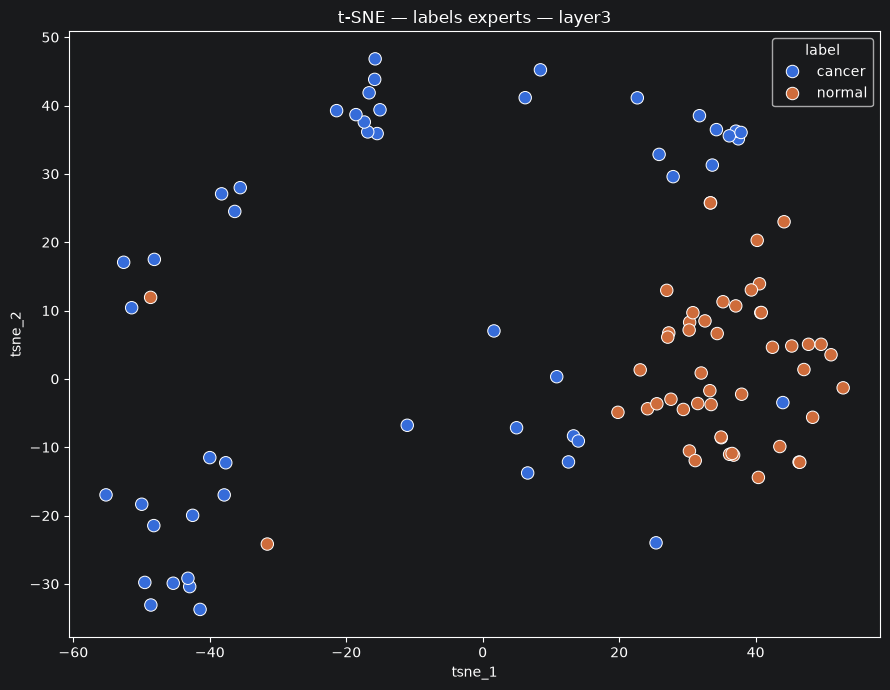

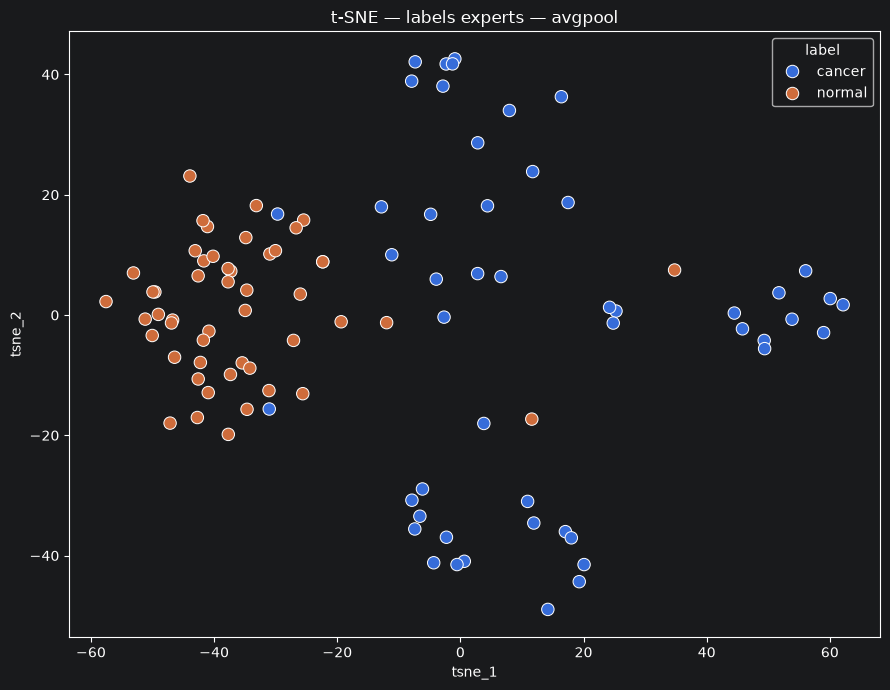

In [170]:
for nom, dataframe in projections.items():
    donnees_fortes = dataframe[
        dataframe["label"].notna()
    ]

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=donnees_fortes,
        x="tsne_1",
        y="tsne_2",
        hue="label",
        s=80,
    )

    plt.title(
        f"t-SNE — labels experts — {nom}"
    )

    plt.tight_layout()
    plt.show()

Ces graphes ne servent pas à entraîner un modèle : ils permettent seulement d’observer si les deux classes semblent naturellement séparables.

10. Fonction d’évaluation des clusters

L’ARI compare deux partitions sans exiger que les numéros de clusters correspondent aux numéros de classes. Une permutation comme cluster 0 = cancer et cluster 1 = normal donne donc le même résultat. Un ARI de 1 correspond à une concordance parfaite, une valeur proche de 0 à un regroupement proche du hasard et une valeur négative à une forte discordance.

Le score de silhouette varie de -1 à 1 : une valeur élevée indique des groupes mieux séparés, une valeur proche de zéro des groupes superposés et une valeur négative des affectations potentiellement incohérentes.

Cellule Code

In [171]:
def evaluer_clustering(
    representation: str,
    algorithme: str,
    X: np.ndarray,
    labels_clusters: np.ndarray,
    parametres: dict,
) -> dict:
    """
    Évalue un clustering avec des métriques internes et l'ARI.
    """

    labels_clusters = np.asarray(
        labels_clusters
    )

    masque_hors_bruit = (
        labels_clusters != -1
    )

    clusters_hors_bruit = np.unique(
        labels_clusters[
            masque_hors_bruit
        ]
    )

    nombre_clusters = len(
        clusters_hors_bruit
    )

    resultat = {
        "representation": representation,
        "algorithme": algorithme,
        "parametres": json.dumps(
            parametres,
            ensure_ascii=False,
        ),
        "nombre_clusters": nombre_clusters,
        "nombre_bruit": int(
            np.sum(~masque_hors_bruit)
        ),
        "pourcentage_bruit": float(
            np.mean(~masque_hors_bruit) * 100
        ),
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "ari_labels_forts": np.nan,
        "couverture_labels_forts": np.nan,
    }

    if (
        nombre_clusters >= 2
        and masque_hors_bruit.sum()
        > nombre_clusters
    ):
        X_evaluation = X[
            masque_hors_bruit
        ]

        labels_evaluation = labels_clusters[
            masque_hors_bruit
        ]

        resultat["silhouette"] = float(
            silhouette_score(
                X_evaluation,
                labels_evaluation,
            )
        )

        resultat["davies_bouldin"] = float(
            davies_bouldin_score(
                X_evaluation,
                labels_evaluation,
            )
        )

        resultat[
            "calinski_harabasz"
        ] = float(
            calinski_harabasz_score(
                X_evaluation,
                labels_evaluation,
            )
        )

    clusters_forts = labels_clusters[
        strong_mask
    ]

    resultat["ari_labels_forts"] = float(
        adjusted_rand_score(
            y_strong,
            clusters_forts,
        )
    )

    resultat[
        "couverture_labels_forts"
    ] = float(
        np.mean(clusters_forts != -1)
        * 100
    )

    return resultat

11. K-Means et clustering hiérarchique

K-Means sera explicitement configuré avec deux clusters. Le clustering agglomératif fusionne progressivement les groupes ; nous l’utilisons également avec deux clusters et le critère de Ward.

Cellule Code

In [172]:
resultats = []
predictions = {}
modeles = {}

for nom, espace in espaces.items():
    X = espace["X_clustering"]

    kmeans = KMeans(
        n_clusters=2,
        n_init=50,
        random_state=RANDOM_STATE,
    )

    labels_kmeans = kmeans.fit_predict(
        X
    )

    predictions[
        (nom, "KMeans")
    ] = labels_kmeans

    modeles[
        (nom, "KMeans")
    ] = kmeans

    resultats.append(
        evaluer_clustering(
            representation=nom,
            algorithme="KMeans",
            X=X,
            labels_clusters=labels_kmeans,
            parametres={
                "n_clusters": 2,
                "n_init": 50,
            },
        )
    )

    agglomeratif = AgglomerativeClustering(
        n_clusters=2,
        linkage="ward",
    )

    labels_agglomeratif = (
        agglomeratif.fit_predict(X)
    )

    predictions[
        (nom, "Agglomerative")
    ] = labels_agglomeratif

    modeles[
        (nom, "Agglomerative")
    ] = agglomeratif

    resultats.append(
        evaluer_clustering(
            representation=nom,
            algorithme="Agglomerative",
            X=X,
            labels_clusters=(
                labels_agglomeratif
            ),
            parametres={
                "n_clusters": 2,
                "linkage": "ward",
            },
        )
    )

12. Recherche DBSCAN

Contrairement à K-Means, DBSCAN ne permet pas d’imposer directement deux clusters. Il détecte les zones denses et peut également classer certains points comme bruit avec le label -1. Nous rechercherons donc une configuration donnant idéalement deux clusters sans utiliser les labels experts pour sélectionner eps.

Cellule Code

In [173]:
def rechercher_dbscan(
    representation: str,
    X: np.ndarray,
) -> tuple[pd.DataFrame, dict]:
    """
    Teste plusieurs paramètres DBSCAN à partir des distances
    de voisinage.

    Une clé textuelle est utilisée pour eps afin d'éviter
    les problèmes de précision des nombres flottants.
    """

    lignes = []
    candidats = {}

    min_samples_values = [
        5,
        10,
        15,
        20,
    ]

    quantiles_eps = [
        0.70,
        0.75,
        0.80,
        0.85,
        0.90,
        0.92,
        0.94,
        0.96,
        0.98,
    ]

    for min_samples in min_samples_values:
        voisins = NearestNeighbors(
            n_neighbors=min_samples,
            n_jobs=-1,
        )

        voisins.fit(X)

        distances, _ = voisins.kneighbors(X)
        distances_k = distances[:, -1]

        eps_values = np.unique(
            np.quantile(
                distances_k,
                quantiles_eps,
            )
        )

        for eps in eps_values:
            eps_value = float(eps)

            # Clé stable utilisée dans le dictionnaire.
            eps_key = f"{eps_value:.6f}"

            modele = DBSCAN(
                eps=eps_value,
                min_samples=min_samples,
                n_jobs=-1,
            )

            labels = modele.fit_predict(X)

            cle = (
                representation,
                eps_key,
                int(min_samples),
            )

            candidats[cle] = {
                "modele": modele,
                "labels": labels,
            }

            lignes.append(
                evaluer_clustering(
                    representation=representation,
                    algorithme="DBSCAN",
                    X=X,
                    labels_clusters=labels,
                    parametres={
                        "eps": float(eps_key),
                        "min_samples": int(min_samples),
                    },
                )
            )

    return pd.DataFrame(lignes), candidats

In [174]:
resultats_dbscan = []
candidats_dbscan = {}

for nom, espace in espaces.items():
    dataframe_dbscan, candidats = (
        rechercher_dbscan(
            representation=nom,
            X=espace["X_clustering"],
        )
    )

    resultats_dbscan.append(
        dataframe_dbscan
    )

    candidats_dbscan.update(
        candidats
    )

df_dbscan = pd.concat(
    resultats_dbscan,
    ignore_index=True,
)

display(
    df_dbscan.sort_values(
        [
            "nombre_clusters",
            "silhouette",
        ],
        ascending=[
            True,
            False,
        ],
    ).head(20)
)

,representation,algorithme,parametres,nombre_clusters,nombre_bruit,pourcentage_bruit,silhouette,davies_bouldin,calinski_harabasz,ari_labels_forts,couverture_labels_forts
6,layer3,DBSCAN,"{""eps"": 34.842686, ""min_samples"": 5}",1,60,3.984064,NaN,NaN,NaN,-0.000777,97.0
7,layer3,DBSCAN,"{""eps"": 36.028802, ""min_samples"": 5}",1,45,2.988048,NaN,NaN,NaN,-0.000793,98.0
8,layer3,DBSCAN,"{""eps"": 39.614523, ""min_samples"": 5}",1,18,1.195219,NaN,NaN,NaN,0.000000,100.0
9,layer3,DBSCAN,"{""eps"": 28.880721, ""min_samples"": 10}",1,271,17.994688,NaN,NaN,NaN,0.108500,73.0
10,layer3,DBSCAN,"{""eps"": 29.797612, ""min_samples"": 10}",1,223,14.807437,NaN,NaN,NaN,0.095736,76.0
11,layer3,DBSCAN,"{""eps"": 31.045404, ""min_samples"": 10}",1,174,11.553785,NaN,NaN,NaN,0.051468,80.0
12,layer3,DBSCAN,"{""eps"": 32.720764, ""min_samples"": 10}",1,123,8.167331,NaN,NaN,NaN,-0.002044,90.0
13,layer3,DBSCAN,"{""eps"": 34.797199, ""min_samples"": 10}",1,79,5.245684,NaN,NaN,NaN,0.000049,96.0
14,layer3,DBSCAN,"{""eps"": 35.653309, ""min_samples"": 10}",1,59,3.917663,NaN,NaN,NaN,-0.000793,98.0
15,layer3,DBSCAN,"{""eps"": 36.77704, ""min_samples"": 10}",1,41,2.722444,NaN,NaN,NaN,0.000000,99.0


13. Sélection interne du meilleur DBSCAN

Nous privilégions :

exactement deux clusters ;
une silhouette élevée ;
un faible pourcentage de bruit.

L’ARI n’intervient pas dans cette sélection.

In [175]:
for nom in espaces:
    candidats_deux_clusters = (
        df_dbscan[
            (df_dbscan["representation"] == nom)
            & (df_dbscan["nombre_clusters"] == 2)
            & (df_dbscan["silhouette"].notna())
        ]
        .sort_values(
            [
                "silhouette",
                "pourcentage_bruit",
            ],
            ascending=[
                False,
                True,
            ],
        )
    )

    if candidats_deux_clusters.empty:
        print(
            f"Aucun DBSCAN à deux clusters pour {nom}."
        )
        continue

    meilleur = candidats_deux_clusters.iloc[0]

    parametres = json.loads(
        meilleur["parametres"]
    )

    # Même représentation textuelle que lors de la création.
    eps_key = f"{float(parametres['eps']):.6f}"

    cle = (
        nom,
        eps_key,
        int(parametres["min_samples"]),
    )

    candidat = candidats_dbscan[cle]

    predictions[
        (nom, "DBSCAN")
    ] = candidat["labels"]

    modeles[
        (nom, "DBSCAN")
    ] = candidat["modele"]

    resultats.append(
        meilleur.to_dict()
    )

    print(
        f"DBSCAN sélectionné pour {nom} : "
        f"eps={parametres['eps']}, "
        f"min_samples={parametres['min_samples']}, "
        f"silhouette={meilleur['silhouette']:.4f}, "
        f"bruit={meilleur['pourcentage_bruit']:.2f} %"
    )

DBSCAN sélectionné pour layer3 : eps=33.743122, min_samples=5, silhouette=0.1229, bruit=5.58 %
Aucun DBSCAN à deux clusters pour avgpool.


14. Comparer les résultats

In [176]:
df_resultats = pd.DataFrame(
    resultats
)

df_resultats = df_resultats.sort_values(
    [
        "ari_labels_forts",
        "silhouette",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)

display(
    df_resultats[
        [
            "representation",
            "algorithme",
            "nombre_clusters",
            "pourcentage_bruit",
            "silhouette",
            "davies_bouldin",
            "calinski_harabasz",
            "ari_labels_forts",
            "couverture_labels_forts",
            "parametres",
        ]
    ]
)

,representation,algorithme,nombre_clusters,pourcentage_bruit,silhouette,davies_bouldin,calinski_harabasz,ari_labels_forts,couverture_labels_forts,parametres
0,avgpool,Agglomerative,2,0.000000,0.049917,3.883985,81.748675,0.457233,100.0,"{""n_clusters"": 2, ""linkage"": ""ward""}"
1,layer3,KMeans,2,0.000000,0.113975,2.738350,193.027774,0.430234,100.0,"{""n_clusters"": 2, ""n_init"": 50}"
2,layer3,Agglomerative,2,0.000000,0.102597,2.907993,172.127825,0.430234,100.0,"{""n_clusters"": 2, ""linkage"": ""ward""}"
3,avgpool,KMeans,2,0.000000,0.142500,3.861937,92.691672,0.123523,100.0,"{""n_clusters"": 2, ""n_init"": 50}"
4,layer3,DBSCAN,2,5.577689,0.122918,1.671584,10.296357,-0.002284,94.0,"{""eps"": 33.743122, ""min_samples"": 5}"


15. Visualiser les clusters en PCA

In [177]:
def afficher_clusters_pca(
    representation: str,
    algorithme: str,
) -> None:
    """
    Affiche en PCA 2D les clusters d'un algorithme.
    """

    projection = projections[
        representation
    ].copy()

    projection["cluster"] = (
        predictions[
            (representation, algorithme)
        ]
        .astype(str)
    )

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=projection,
        x="pca_1",
        y="pca_2",
        hue="cluster",
        s=35,
        alpha=0.75,
    )

    plt.title(
        f"{algorithme} — {representation} — PCA"
    )

    plt.tight_layout()
    plt.show()

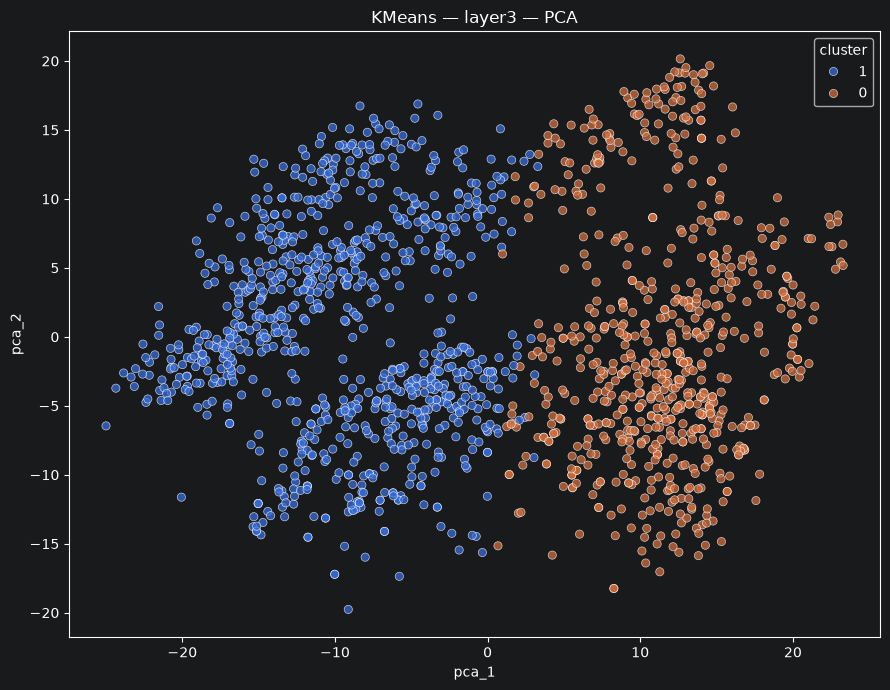

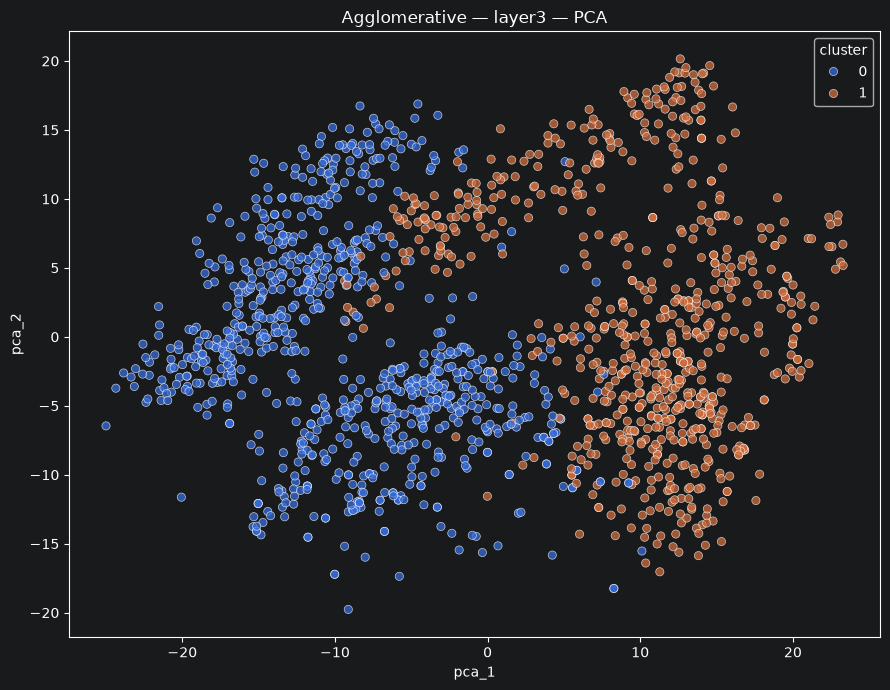

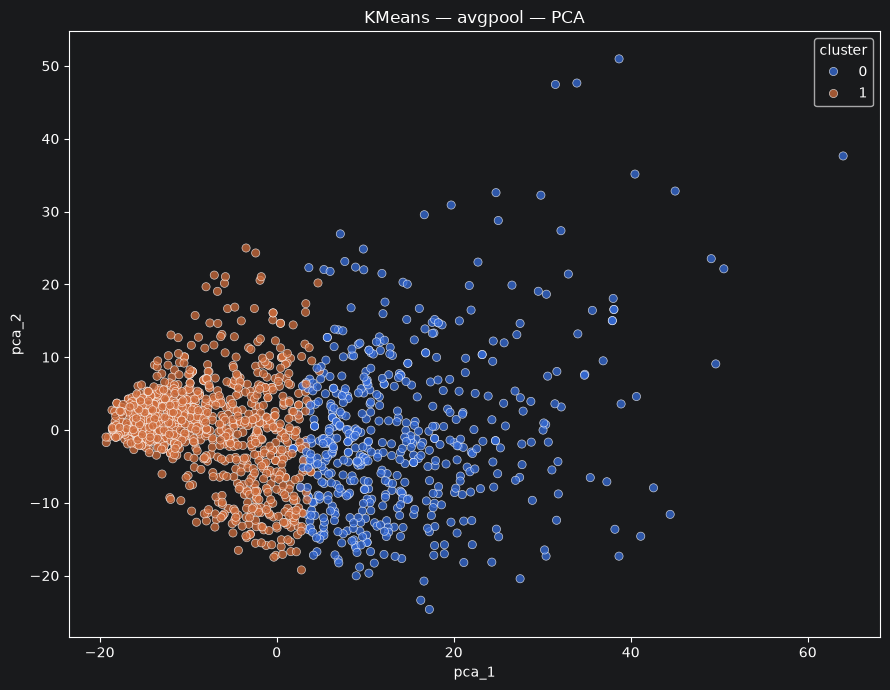

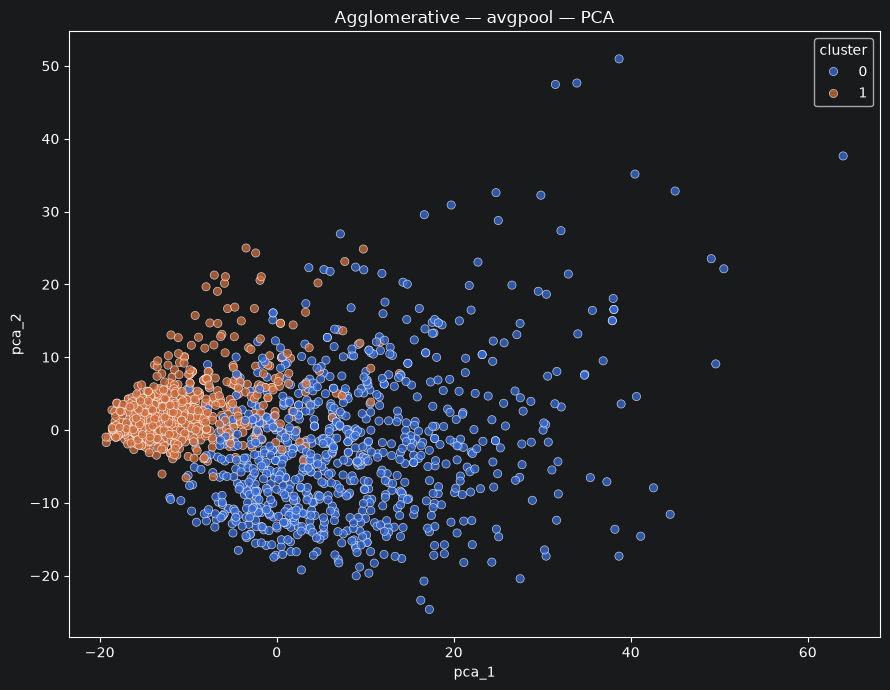

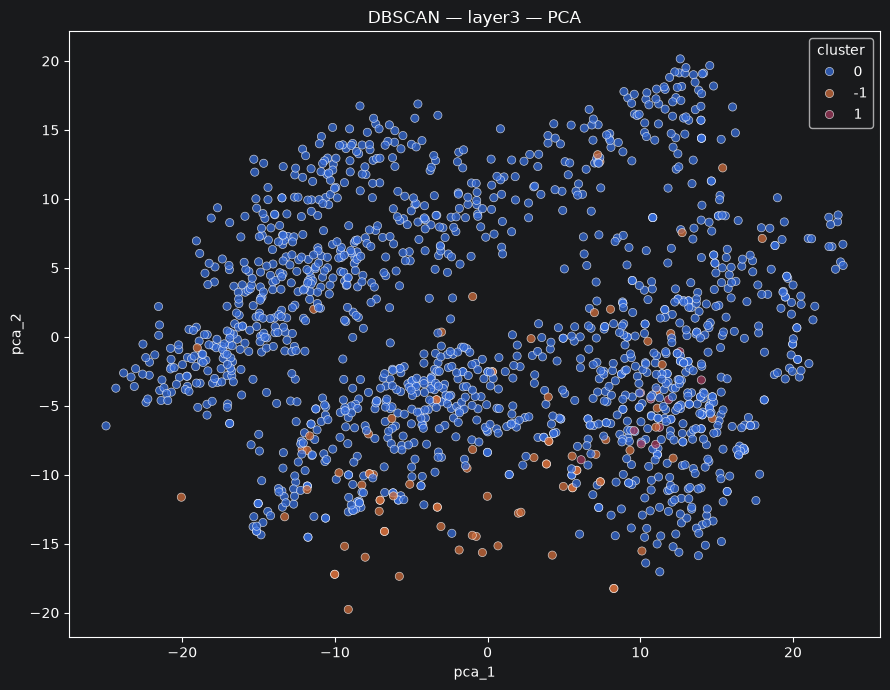

In [178]:
for cle in predictions:
    representation, algorithme = cle

    afficher_clusters_pca(
        representation,
        algorithme,
    )

## 16. Sélection du clustering retenu

La représentation `avgpool` associée au clustering agglomératif est
retenue pour produire les labels faibles.

Cette configuration présente :

- le meilleur ARI observé : environ 0,457 ;
- deux clusters ;
- une couverture de 100 % des références fortement labellisées ;
- aucun point classé comme bruit.

Le score de silhouette reste faible. Cela indique que les deux groupes
ne sont pas nettement séparés dans l'espace des features.

Les résultats doivent donc être interprétés comme des annotations
faibles destinées à l'étape semi-supervisée, et non comme des diagnostics
médicaux fiables.

In [179]:
REPRESENTATION_RETENUE = "avgpool"
ALGORITHME_RETENU = "Agglomerative"

cle_modele_retenu = (
    REPRESENTATION_RETENUE,
    ALGORITHME_RETENU,
)

labels_clusters_retenus = predictions[
    cle_modele_retenu
].copy()

X_retenu = espaces[
    REPRESENTATION_RETENUE
]["X_clustering"]

ligne_modele_retenu = (
    df_resultats[
        (df_resultats["representation"] == REPRESENTATION_RETENUE)
        & (df_resultats["algorithme"] == ALGORITHME_RETENU)
    ]
    .iloc[0]
)

print(
    f"Représentation retenue : "
    f"{REPRESENTATION_RETENUE}"
)

print(
    f"Algorithme retenu : "
    f"{ALGORITHME_RETENU}"
)

print(
    f"ARI : "
    f"{ligne_modele_retenu['ari_labels_forts']:.4f}"
)

print(
    f"Silhouette : "
    f"{ligne_modele_retenu['silhouette']:.4f}"
)

print(
    f"Nombre de clusters : "
    f"{ligne_modele_retenu['nombre_clusters']}"
)

print(
    f"Nombre de points bruités : "
    f"{ligne_modele_retenu['nombre_bruit']}"
)

Représentation retenue : avgpool
Algorithme retenu : Agglomerative
ARI : 0.4572
Silhouette : 0.0499
Nombre de clusters : 2
Nombre de points bruités : 0


## 17. Interprétation des identifiants de clusters

Les numéros de clusters n'ont aucune signification médicale directe.

Une table de contingence est construite à partir des 100 références
expertes. Une correspondance bijective est ensuite recherchée entre :

- les identifiants des clusters ;
- les classes expertes `normal` et `cancer`.

Cette opération ne modifie pas le clustering. Elle sert uniquement à
donner une interprétation aux deux groupes déjà construits.

In [180]:
from scipy.optimize import linear_sum_assignment

In [181]:
clusters_strong = labels_clusters_retenus[
    strong_mask
]

cluster_ids = np.sort(
    np.unique(labels_clusters_retenus)
)

expert_label_ids = np.sort(
    np.unique(y_strong)
)

table_contingence = pd.crosstab(
    pd.Series(
        clusters_strong,
        name="cluster_id",
    ),
    pd.Series(
        y_strong,
        name="expert_label_id",
    ),
)

table_contingence = table_contingence.reindex(
    index=cluster_ids,
    columns=expert_label_ids,
    fill_value=0,
)

display(table_contingence)

expert_label_id,0,1
cluster_id,,
0,2,36
1,48,14


18. Trouver la meilleure correspondance globale

In [182]:
indices_clusters, indices_labels = (
    linear_sum_assignment(
        -table_contingence.to_numpy()
    )
)

cluster_to_label_id = {
    int(cluster_ids[index_cluster]): int(
        expert_label_ids[index_label]
    )
    for index_cluster, index_label in zip(
        indices_clusters,
        indices_labels,
    )
}

label_reference = (
    df_strong_reference[
        [
            "label_id",
            "label",
        ]
    ]
    .drop_duplicates()
)

label_id_to_name = {
    int(ligne["label_id"]): str(
        ligne["label"]
    )
    for _, ligne in label_reference.iterrows()
}

df_mapping_clusters = pd.DataFrame(
    [
        {
            "cluster_id": cluster_id,
            "weak_label_id": label_id,
            "weak_label": label_id_to_name[
                label_id
            ],
        }
        for cluster_id, label_id
        in sorted(
            cluster_to_label_id.items()
        )
    ]
)

display(df_mapping_clusters)

,cluster_id,weak_label_id,weak_label
0,0,1,cancer
1,1,0,normal


19. Mesurer la concordance après interprétation

L’ARI n’a pas besoin de cette correspondance, mais elle permet de calculer une accuracy descriptive sur les 100 références expertes.

In [183]:
def convertir_clusters_en_labels(
    clusters: np.ndarray,
    mapping: dict[int, int],
) -> np.ndarray:
    """
    Convertit les identifiants des clusters en identifiants
    de classes interprétés.
    """

    return np.array(
        [
            mapping.get(
                int(cluster_id),
                -1,
            )
            for cluster_id in clusters
        ],
        dtype=int,
    )

In [184]:
labels_interpretes_strong = (
    convertir_clusters_en_labels(
        clusters=clusters_strong,
        mapping=cluster_to_label_id,
    )
)

accuracy_interpretation = float(
    np.mean(
        labels_interpretes_strong
        == y_strong
    )
)

print(
    "Accuracy descriptive après correspondance : "
    f"{accuracy_interpretation:.4f}"
)

Accuracy descriptive après correspondance : 0.8400


20. Afficher la table de contingence

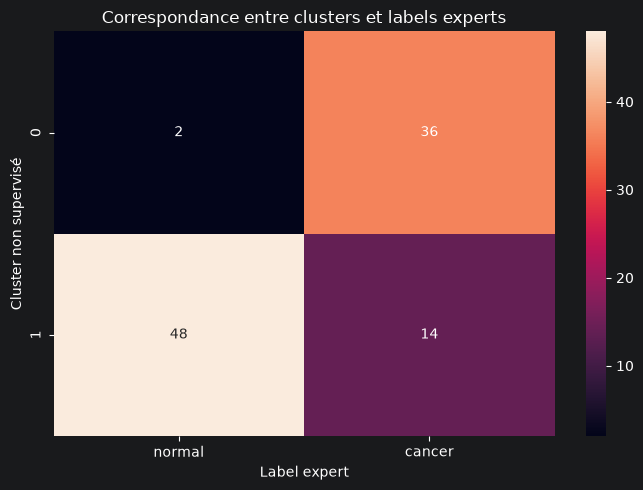

In [185]:
table_contingence_noms = (
    table_contingence.copy()
)

table_contingence_noms.columns = [
    label_id_to_name[
        int(label_id)
    ]
    for label_id
    in table_contingence_noms.columns
]

plt.figure(figsize=(7, 5))

sns.heatmap(
    table_contingence_noms,
    annot=True,
    fmt="d",
)

plt.title(
    "Correspondance entre clusters et labels experts"
)

plt.xlabel("Label expert")
plt.ylabel("Cluster non supervisé")

plt.tight_layout()
plt.show()

Ce graphique permet de voir combien d’images normal et cancer se trouvent dans chaque cluster.

21. Estimer un indicateur de confiance

Le clustering agglomératif ne fournit pas directement une probabilité. Nous allons donc construire un indice de confiance relatif, qui ne devra pas être interprété comme une probabilité médicale.

Pour chaque image :

on calcule sa distance au centroïde du cluster attribué ;
on calcule sa distance au centroïde de l’autre cluster ;
plus elle est proche de son cluster et éloignée de l’autre, plus l’indice est élevé.

## 18. Indicateur de confiance relatif

Le clustering ne produit pas de probabilité prédictive.

Un indicateur géométrique est donc calculé à partir des distances aux
centroïdes des deux clusters.

Cet indicateur :

- est compris entre 0 et 1 ;
- vaut environ 0,5 près de la frontière entre les groupes ;
- augmente lorsque l'observation est plus proche de son propre cluster ;
- ne constitue pas une probabilité de cancer.

Une observation est considérée comme incertaine lorsque cet indicateur
est inférieur à 0,60.

In [186]:
cluster_ids_retenus = np.sort(
    np.unique(labels_clusters_retenus)
)

centroides = np.vstack(
    [
        X_retenu[
            labels_clusters_retenus
            == cluster_id
        ].mean(axis=0)
        for cluster_id
        in cluster_ids_retenus
    ]
)

matrice_distances = np.column_stack(
    [
        np.linalg.norm(
            X_retenu - centroide,
            axis=1,
        )
        for centroide in centroides
    ]
)

cluster_to_position = {
    int(cluster_id): position
    for position, cluster_id
    in enumerate(cluster_ids_retenus)
}

positions_clusters_assignes = np.array(
    [
        cluster_to_position[
            int(cluster_id)
        ]
        for cluster_id
        in labels_clusters_retenus
    ],
    dtype=int,
)

indices_lignes = np.arange(
    len(labels_clusters_retenus)
)

distance_cluster_assigne = (
    matrice_distances[
        indices_lignes,
        positions_clusters_assignes,
    ]
)

distances_autres_clusters = (
    matrice_distances.copy()
)

distances_autres_clusters[
    indices_lignes,
    positions_clusters_assignes,
] = np.inf

distance_cluster_alternatif = (
    distances_autres_clusters.min(
        axis=1
    )
)

confidence_relative = (
    distance_cluster_alternatif
    / (
        distance_cluster_assigne
        + distance_cluster_alternatif
        + 1e-12
    )
)

SEUIL_INCERTITUDE = 0.60

is_uncertain = (
    confidence_relative
    < SEUIL_INCERTITUDE
)

print(
    f"Confiance minimale : "
    f"{confidence_relative.min():.4f}"
)

print(
    f"Confiance moyenne : "
    f"{confidence_relative.mean():.4f}"
)

print(
    f"Confiance maximale : "
    f"{confidence_relative.max():.4f}"
)

print(
    f"Images incertaines : "
    f"{is_uncertain.sum()} / "
    f"{len(is_uncertain)}"
)

Confiance minimale : 0.4577
Confiance moyenne : 0.5337
Confiance maximale : 0.6433
Images incertaines : 1448 / 1506


## 19. Tableau d'évaluation fortement labellisé

Les 100 labels experts sont conservés dans un tableau réservé à
l'évaluation.

Ce tableau ne sera pas utilisé comme fichier de labels faibles et ne
sera pas concaténé avec les 1 406 images non annotées.

In [187]:
df_strong_assignments = (
    df_strong_reference[
        [
            "chemin_relatif",
            "nom_fichier",
            "categorie",
            "label",
            "label_id",
        ]
    ]
    .copy()
)

df_strong_assignments = (
    df_strong_assignments.rename(
        columns={
            "label": "expert_label",
            "label_id": "expert_label_id",
        }
    )
)

df_strong_assignments[
    "expert_label_id"
] = (
    df_strong_assignments[
        "expert_label_id"
    ]
    .astype(int)
)

df_strong_assignments[
    "cluster_id"
] = clusters_strong

df_strong_assignments[
    "cluster_label_id"
] = labels_interpretes_strong

df_strong_assignments[
    "cluster_label"
] = [
    label_id_to_name[
        int(label_id)
    ]
    for label_id
    in labels_interpretes_strong
]

df_strong_assignments[
    "correct_assignment"
] = (
    df_strong_assignments[
        "expert_label_id"
    ]
    == df_strong_assignments[
        "cluster_label_id"
    ]
)

df_strong_assignments[
    "confidence_relative"
] = confidence_relative[
    strong_mask
]

df_strong_assignments[
    "is_uncertain"
] = is_uncertain[
    strong_mask
]

display(
    df_strong_assignments.head()
)

,chemin_relatif,nom_fichier,categorie,expert_label,expert_label_id,cluster_id,cluster_label_id,cluster_label,correct_assignment,confidence_relative,is_uncertain
0,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,cancer,cancer,1,0,1,cancer,True,0.527474,True
1,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,cancer,cancer,1,1,0,normal,False,0.574207,True
2,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,0f718241-8f63-4b55-81ce-315324b51069.jpg,cancer,cancer,1,1,0,normal,False,0.509414,True
3,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,cancer,cancer,1,0,1,cancer,True,0.506120,True
4,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,cancer,cancer,1,0,1,cancer,True,0.526094,True


## 20. Création des labels faibles

Le tableau suivant contient exclusivement les 1 406 images qui ne
possédaient aucun label expert.

Les colonnes `weak_label` et `weak_label_id` sont dérivées du cluster
attribué et de la correspondance établie avec les références expertes.

Les labels experts ne sont ni copiés ni ajoutés à ce tableau.

In [188]:
clusters_unlabeled = (
    labels_clusters_retenus[
        unlabeled_mask
    ]
)

weak_label_ids = (
    convertir_clusters_en_labels(
        clusters=clusters_unlabeled,
        mapping=cluster_to_label_id,
    )
)

df_weak_labels = (
    df_unlabeled_reference[
        [
            "chemin_relatif",
            "nom_fichier",
            "categorie",
        ]
    ]
    .copy()
)

df_weak_labels[
    "cluster_id"
] = clusters_unlabeled

df_weak_labels[
    "weak_label_id"
] = weak_label_ids

df_weak_labels[
    "weak_label"
] = [
    label_id_to_name[
        int(label_id)
    ]
    if int(label_id) in label_id_to_name
    else "indetermine"
    for label_id
    in weak_label_ids
]

df_weak_labels[
    "confidence_relative"
] = confidence_relative[
    unlabeled_mask
]

df_weak_labels[
    "is_uncertain"
] = is_uncertain[
    unlabeled_mask
]

df_weak_labels[
    "representation"
] = REPRESENTATION_RETENUE

df_weak_labels[
    "algorithme"
] = ALGORITHME_RETENU

df_weak_labels[
    "label_source"
] = "clustering_weak_label"

display(
    df_weak_labels.head()
)

,chemin_relatif,nom_fichier,categorie,cluster_id,weak_label_id,weak_label,confidence_relative,is_uncertain,representation,algorithme,label_source
0,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,001b158a-7af8-451e-bf31-3a9116265f3a.jpg,sans_label,0,1,cancer,0.515933,True,avgpool,Agglomerative,clustering_weak_label
1,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,sans_label,1,0,normal,0.520503,True,avgpool,Agglomerative,clustering_weak_label
2,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,00455a62-f79f-4072-9a23-4951e759acdc.jpg,sans_label,1,0,normal,0.577160,True,avgpool,Agglomerative,clustering_weak_label
3,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,sans_label,1,0,normal,0.521548,True,avgpool,Agglomerative,clustering_weak_label
4,data/raw/mri_dataset_brain_cancer_oc/sans_labe...,005d9a37-8894-4eb5-8367-1015d4a43638.jpg,sans_label,0,1,cancer,0.532070,True,avgpool,Agglomerative,clustering_weak_label


In [189]:
resume_labels_faibles = (
    df_weak_labels.groupby(
        [
            "weak_label",
            "is_uncertain",
        ],
        dropna=False,
    )
    .size()
    .reset_index(
        name="nombre_images"
    )
)

display(
    resume_labels_faibles
)

print(
    f"Nombre total de labels faibles : "
    f"{len(df_weak_labels)}"
)

print(
    f"Nombre d'images incertaines : "
    f"{df_weak_labels['is_uncertain'].sum()}"
)

,weak_label,is_uncertain,nombre_images
0,cancer,True,806
1,normal,False,52
2,normal,True,548


Nombre total de labels faibles : 1406
Nombre d'images incertaines : 1354


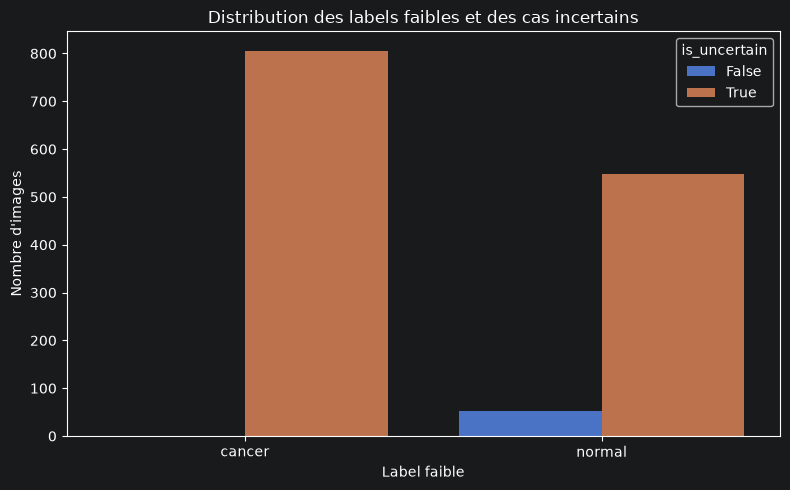

In [190]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_weak_labels,
    x="weak_label",
    hue="is_uncertain",
)

plt.title(
    "Distribution des labels faibles et des cas incertains"
)

plt.xlabel("Label faible")
plt.ylabel("Nombre d'images")

plt.tight_layout()
plt.show()

## 21. Contrôles de séparation

Les contrôles suivants garantissent que :

- le tableau fort contient exactement 100 images ;
- le tableau faible contient exactement 1 406 images ;
- aucune image ne figure dans les deux tableaux ;
- aucun label expert n'est présent dans le tableau faible ;
- les labels faibles ne remplacent jamais les labels experts.

In [191]:
assert len(
    df_strong_assignments
) == 100

assert len(
    df_weak_labels
) == 1406

chemins_strong = set(
    df_strong_assignments[
        "chemin_relatif"
    ]
)

chemins_weak = set(
    df_weak_labels[
        "chemin_relatif"
    ]
)

assert chemins_strong.isdisjoint(
    chemins_weak
)

assert (
    len(chemins_strong)
    + len(chemins_weak)
    == 1506
)

assert "expert_label" not in (
    df_weak_labels.columns
)

assert "expert_label_id" not in (
    df_weak_labels.columns
)

assert (
    df_weak_labels[
        "weak_label"
    ]
    .notna()
    .all()
)

assert (
    df_strong_assignments[
        "expert_label"
    ]
    .notna()
    .all()
)

assert set(
    df_weak_labels[
        "cluster_id"
    ].unique()
) == set(
    cluster_ids_retenus
)

print(
    "Validation réussie : les jeux fortement et "
    "faiblement labellisés sont strictement séparés."
)

Validation réussie : les jeux fortement et faiblement labellisés sont strictement séparés.


In [192]:
STRONG_ASSIGNMENTS_PATH = (
    OUTPUT_DIR
    / "strong_assignments_evaluation_only.csv"
)

WEAK_LABELS_PATH = (
    OUTPUT_DIR
    / "weak_labels_unlabeled_only.csv"
)

CLUSTERING_RESULTS_PATH = (
    OUTPUT_DIR
    / "clustering_results.csv"
)

CLUSTER_MAPPING_PATH = (
    OUTPUT_DIR
    / "cluster_label_mapping.csv"
)

WEAK_LABELING_CONFIG_PATH = (
    OUTPUT_DIR
    / "weak_labeling_config.json"
)

In [193]:
df_strong_assignments.to_csv(
    STRONG_ASSIGNMENTS_PATH,
    index=False,
)

df_weak_labels.to_csv(
    WEAK_LABELS_PATH,
    index=False,
)

df_resultats.to_csv(
    CLUSTERING_RESULTS_PATH,
    index=False,
)

df_mapping_clusters.to_csv(
    CLUSTER_MAPPING_PATH,
    index=False,
)

print(
    f"Références fortes : "
    f"{STRONG_ASSIGNMENTS_PATH}"
)

print(
    f"Labels faibles : "
    f"{WEAK_LABELS_PATH}"
)

print(
    f"Résultats clustering : "
    f"{CLUSTERING_RESULTS_PATH}"
)

print(
    f"Correspondance des clusters : "
    f"{CLUSTER_MAPPING_PATH}"
)

Références fortes : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/clustering/strong_assignments_evaluation_only.csv
Labels faibles : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/clustering/weak_labels_unlabeled_only.csv
Résultats clustering : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/clustering/clustering_results.csv
Correspondance des clusters : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/clustering/cluster_label_mapping.csv


In [194]:
configuration_weak_labeling = {
    "representation": REPRESENTATION_RETENUE,
    "algorithme": ALGORITHME_RETENU,
    "nombre_clusters": int(
        ligne_modele_retenu["nombre_clusters"]
    ),
    "ari_labels_forts": float(
        ligne_modele_retenu["ari_labels_forts"]
    ),
    "silhouette": float(
        ligne_modele_retenu["silhouette"]
    ),
    "davies_bouldin": float(
        ligne_modele_retenu["davies_bouldin"]
    ),
    "calinski_harabasz": float(
        ligne_modele_retenu["calinski_harabasz"]
    ),
    "accuracy_apres_mapping": float(
        accuracy_interpretation
    ),
    "nombre_labels_experts": int(
        len(df_strong_assignments)
    ),
    "nombre_labels_faibles": int(
        len(df_weak_labels)
    ),
    "seuil_incertitude": float(
        SEUIL_INCERTITUDE
    ),
    "nombre_labels_faibles_incertains": int(
        df_weak_labels["is_uncertain"].sum()
    ),
    "cluster_to_label_id": {
        str(cluster_id): int(label_id)
        for cluster_id, label_id
        in cluster_to_label_id.items()
    },
    "label_id_to_name": {
        str(label_id): str(label_name)
        for label_id, label_name
        in label_id_to_name.items()
    },
}

with WEAK_LABELING_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as fichier:
    json.dump(
        configuration_weak_labeling,
        fichier,
        indent=2,
        ensure_ascii=False,
    )

display(
    pd.DataFrame(
        configuration_weak_labeling.items(),
        columns=[
            "parametre",
            "valeur",
        ],
    )
)

,parametre,valeur
0,representation,avgpool
1,algorithme,Agglomerative
2,nombre_clusters,2
3,ari_labels_forts,0.457233
4,silhouette,0.049917
5,davies_bouldin,3.883985
6,calinski_harabasz,81.748675
7,accuracy_apres_mapping,0.84
8,nombre_labels_experts,100
9,nombre_labels_faibles,1406


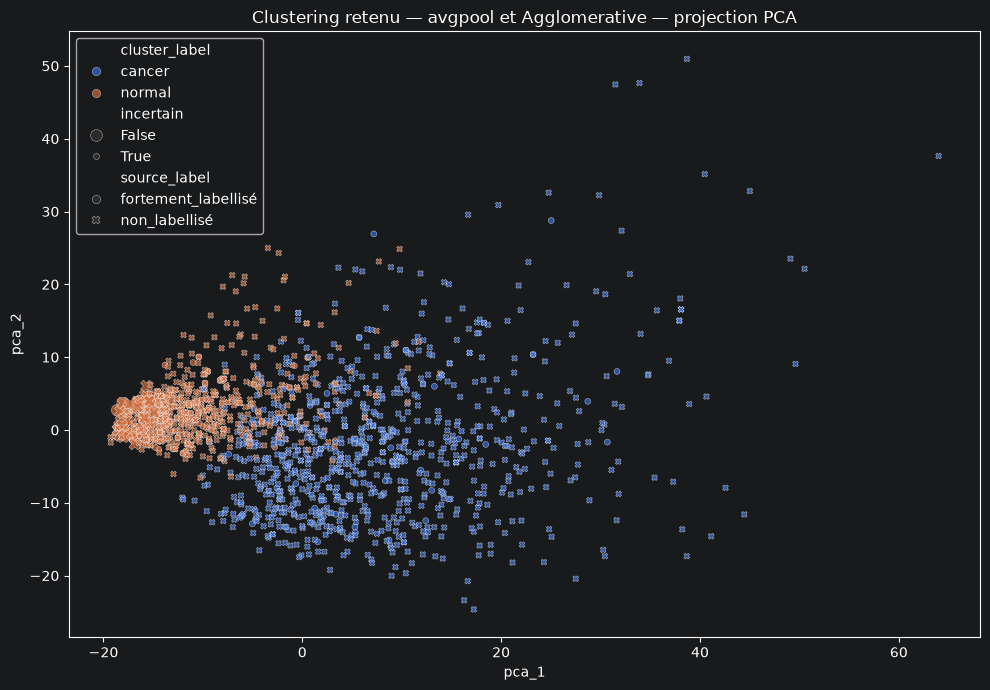

In [195]:
projection_retenue = projections[
    REPRESENTATION_RETENUE
].copy()

projection_retenue[
    "cluster_id"
] = labels_clusters_retenus.astype(
    str
)

labels_interpretes_tous = (
    convertir_clusters_en_labels(
        clusters=labels_clusters_retenus,
        mapping=cluster_to_label_id,
    )
)

projection_retenue[
    "cluster_label"
] = [
    label_id_to_name[
        int(label_id)
    ]
    for label_id
    in labels_interpretes_tous
]

projection_retenue[
    "incertain"
] = is_uncertain

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=projection_retenue,
    x="pca_1",
    y="pca_2",
    hue="cluster_label",
    style="source_label",
    size="incertain",
    alpha=0.70,
)

plt.title(
    "Clustering retenu — avgpool et "
    "Agglomerative — projection PCA"
)

plt.tight_layout()
plt.show()

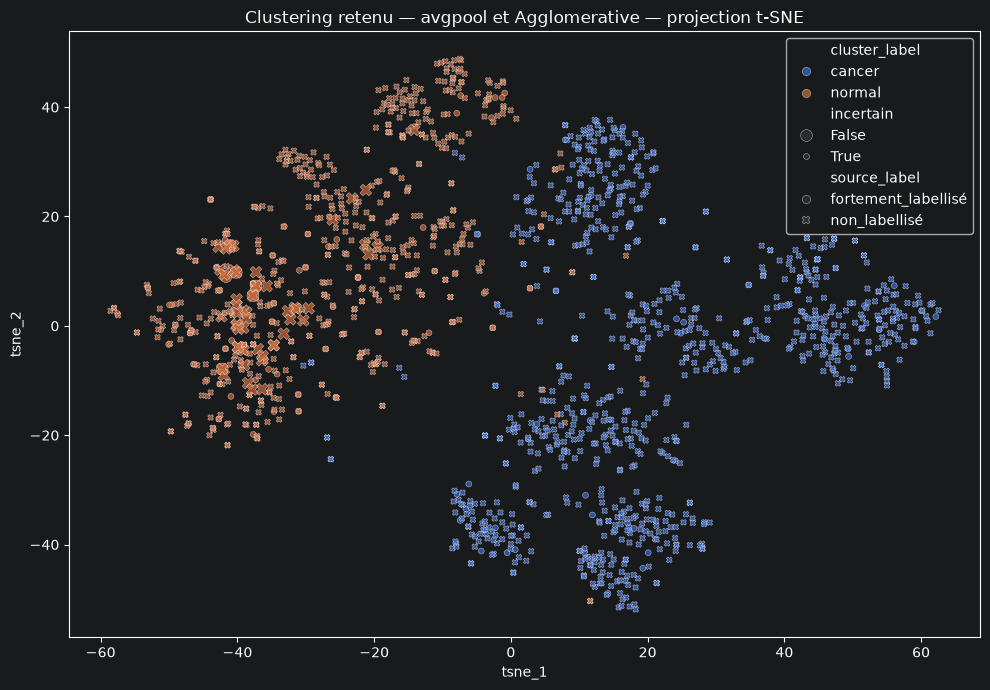

In [196]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=projection_retenue,
    x="tsne_1",
    y="tsne_2",
    hue="cluster_label",
    style="source_label",
    size="incertain",
    alpha=0.70,
)

plt.title(
    "Clustering retenu — avgpool et "
    "Agglomerative — projection t-SNE"
)

plt.tight_layout()
plt.show()

## 22. Interprétation des résultats

La comparaison des modèles montre que le clustering agglomératif
appliqué aux features `avgpool` obtient le meilleur ARI, avec une valeur
d'environ **0,457**.

Cette valeur indique qu'une partie de la structure détectée sans
supervision correspond aux classes expertes `normal` et `cancer`.
La concordance reste toutefois imparfaite.

Le score de silhouette d'environ **0,050** montre que les deux clusters
sont peu séparés dans l'espace complet utilisé pour le clustering.
Les projections PCA et t-SNE doivent donc être interprétées avec
prudence : une séparation visuelle en deux dimensions ne garantit pas
une séparation nette dans l'espace d'origine.

Les résultats des autres méthodes renforcent cette interprétation :

- K-Means sur `layer3` obtient un ARI proche, d'environ 0,430, avec une
  silhouette plus élevée ;
- le clustering agglomératif sur `layer3` obtient également un ARI
  d'environ 0,430 ;
- K-Means sur `avgpool` présente une meilleure silhouette, mais un ARI
  nettement inférieur ;
- DBSCAN ne retrouve pas la structure des labels experts, avec un ARI
  proche de zéro, et classe une partie des observations comme bruit.

Les 1 406 annotations générées sont conservées comme propositions de
labels faibles accompagnées d'un indicateur d'incertitude.

Elles ne devront pas être intégrées automatiquement avec le même poids
dans l'étape semi-supervisée. Les observations les plus incertaines
devront être exclues, sous-pondérées ou soumises à une validation
complémentaire.

## 23. Definition of Done — Étape 3

L'étape 3 est considérée comme terminée car :

- les embeddings `layer3` et `avgpool` ont été standardisés ;
- une PCA conservant au moins 95 % de la variance a été réalisée ;
- des projections PCA et t-SNE en deux dimensions ont été produites ;
- K-Means, DBSCAN et le clustering agglomératif ont été testés ;
- K-Means et le clustering agglomératif ont utilisé exactement deux
  groupes ;
- plusieurs configurations DBSCAN ont été évaluées ;
- les scores de silhouette, Davies-Bouldin et Calinski-Harabasz ont été
  calculés ;
- l'ARI a été calculé uniquement à partir des 100 références expertes ;
- les labels experts n'ont jamais été transmis aux algorithmes de
  clustering ;
- le modèle retenu est explicitement documenté ;
- les clusters ont été interprétés à partir des références expertes ;
- un indicateur de confiance relatif a été calculé ;
- les observations incertaines sont explicitement signalées ;
- les 100 références fortement labellisées sont conservées dans un
  fichier dédié ;
- les 1 406 images sans annotation initiale disposent d'un fichier de
  labels faibles séparé ;
- aucune image n'est présente simultanément dans les deux fichiers ;
- les résultats et la configuration expérimentale sont sauvegardés ;
- les limites méthodologiques et médicales sont documentées.
- la forte proportion d'annotations incertaines est quantifiée et
  documentée comme une limite pour l'étape semi-supervisée ;
  - les observations incertaines sont explicitement signalées ;

La Definition of Done de l'étape 3 est atteinte.

Verdict final

L’analyse non supervisée demandée est réalisée et les données fortes/faibles sont correctement séparées.

L’étape 3 peut être déclarée terminée après avoir ajouté la précision essentielle suivante :

96,3 % des pseudo-labels sont incertains ; ils ne devront donc pas être tous utilisés directement ou avec le même poids dans le modèle semi-supervisé.

C’est une limite du résultat, pas une erreur de code.